# Week 4 Assignment: Adversarial Perturbations and Low-Rank Sensitivity

In this assignment, you will explore the relationship between the low-rank structure of neural networks and their vulnerability to adversarial attacks.

**Tasks:**
1. Implement the Fast Gradient Sign Method (FGSM).
2. Analyze the Jacobian of the network using SVD.
3. Investigate the effect of weight decay on network sensitivity.

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt

import torchvision
import torchvision.transforms as transforms

np.random.seed(42)
torch.manual_seed(42)

%matplotlib inline

## Data — Fashion-MNIST

Fashion-MNIST: 60k train / 10k test, 28×28 grayscale images, 10 classes
(T-shirt, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Sneaker, Bag,
Ankle boot).

We flatten to 784-dim vectors and normalize to $[0, 1]$. No additional
standardization — pixel values in $[0, 1]$ keep perturbation magnitudes
($\epsilon$) interpretable.

100%|██████████| 26.4M/26.4M [00:02<00:00, 10.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 167kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.16MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 9.70MB/s]


train: torch.Size([60000, 784]), test: torch.Size([10000, 784])


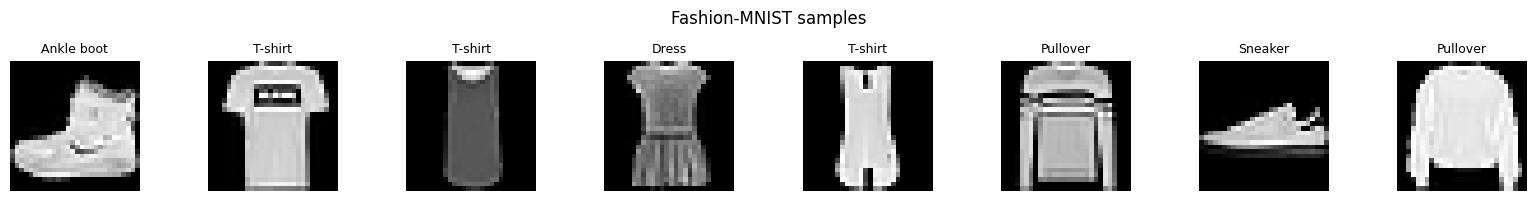

In [ ]:
train_data = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True,
    transform=transforms.ToTensor()
)
test_data = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True,
    transform=transforms.ToTensor()
)

# Flatten to (N, 784), scale to [0, 1]
Xtr = train_data.data.float().reshape(-1, 784) / 255.0
ytr = train_data.targets
Xte = test_data.data.float().reshape(-1, 784) / 255.0
yte = test_data.targets

CLASS_NAMES = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(f"train: {Xtr.shape}, test: {Xte.shape}")

fig, axes = plt.subplots(1, 8, figsize=(16, 2))
for i, ax in enumerate(axes):
    ax.imshow(Xtr[i].reshape(28, 28), cmap='gray')
    ax.set_title(CLASS_NAMES[ytr[i]], fontsize=9)
    ax.axis('off')
plt.suptitle('Fashion-MNIST samples', fontsize=12)
plt.tight_layout()
plt.show()

## Part 1 — Train an MLP on Fashion-MNIST

Architecture: $784 \to 128 \;(\text{ReLU}) \to 64 \;(\text{ReLU}) \to 10$.
Two hidden layers give us two representation bottlenecks to analyze.
Mini-batch Adam with cross-entropy loss. Expect ~88–90% test accuracy.

In [ ]:
class MLP(nn.Module):
    '''Two-hidden-layer MLP for multi-class classification.'''
    def __init__(self, input_dim=784, h1=128, h2=64, n_classes=10):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, h1)
        self.fc2 = nn.Linear(h1, h2)
        self.fc3 = nn.Linear(h2, n_classes)

    def forward(self, x):
        a1 = F.relu(self.fc1(x))
        a2 = F.relu(self.fc2(a1))
        return self.fc3(a2)

    def hidden_features(self, x, layer=1):
        with torch.no_grad():
            a1 = F.relu(self.fc1(x))
            if layer == 1:
                return a1
            return F.relu(self.fc2(a1))


def train_mlp(model, X, y, steps=5000, lr=1e-3, batch_size=512,
              weight_decay=0.0, verbose=True):
    '''Mini-batch Adam training with cross-entropy loss.'''
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    losses = []
    n = X.shape[0]
    for step in range(1, steps + 1):
        idx = torch.randint(0, n, (batch_size,))
        logits = model(X[idx])
        loss = F.cross_entropy(logits, y[idx])
        opt.zero_grad()
        loss.backward()
        opt.step()
        losses.append(loss.item())
        if verbose and step % 1000 == 0:
            print(f"  step {step:5d}: loss = {loss.item():.4f}")
    return losses


def accuracy(model, X, y):
    '''Classification accuracy (argmax).'''
    with torch.no_grad():
        preds = model(X).argmax(dim=1)
    return (preds == y).float().mean().item()

In [ ]:
torch.manual_seed(42)
model = MLP(input_dim=784, h1=128, h2=64)
losses = train_mlp(model, Xtr, ytr, steps=5000, lr=1e-3, batch_size=512)

train_acc = accuracy(model, Xtr, ytr)
test_acc  = accuracy(model, Xte, yte)
print(f"\nMLP: train acc = {train_acc:.4f}, test acc = {test_acc:.4f}")

  step  1000: loss = 0.3543
  step  2000: loss = 0.2987
  step  3000: loss = 0.2563
  step  4000: loss = 0.2289
  step  5000: loss = 0.1829

MLP: train acc = 0.9309, test acc = 0.8830


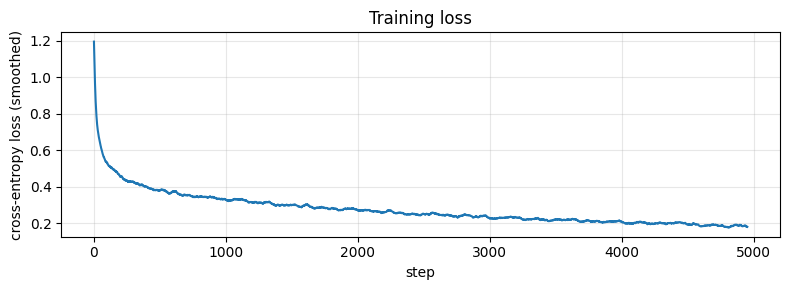

In [ ]:
fig, ax = plt.subplots(figsize=(8, 3))
window = 50
smoothed = np.convolve(losses, np.ones(window)/window, mode='valid')
ax.plot(smoothed)
ax.set_xlabel('step'); ax.set_ylabel('cross-entropy loss (smoothed)')
ax.set_title('Training loss'); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Part 2 — Low-rank structure of the hidden representations

Verify the 'compression' hypothesis. Compute the effective rank of the hidden activations for both layers.

In [ ]:
def compute_svd_stats(H):
    '''Compute SVD, condition number, and effective rank (95% variance).'''
    # 1. Compute SVD using numpy (H is likely a numpy array here)
    # 2. Calculate singular values (S)
    # 3. Compute condition number (sigma_max / sigma_min)
    # 4. Calculate cumulative variance explained (S^2 / sum(S^2))
    # 5. Determine effective rank (number of components to reach 95% variance)
    pass

n_svd = 5000
idx_svd = torch.randperm(len(Xtr))[:n_svd]

# TODO: Extract hidden features using model.hidden_features()
# H_L1 = ...
# H_L2 = ...

# TODO: Convert to numpy and compute stats
# svd_L1 = compute_svd_stats(H_L1)
# svd_L2 = compute_svd_stats(H_L2)

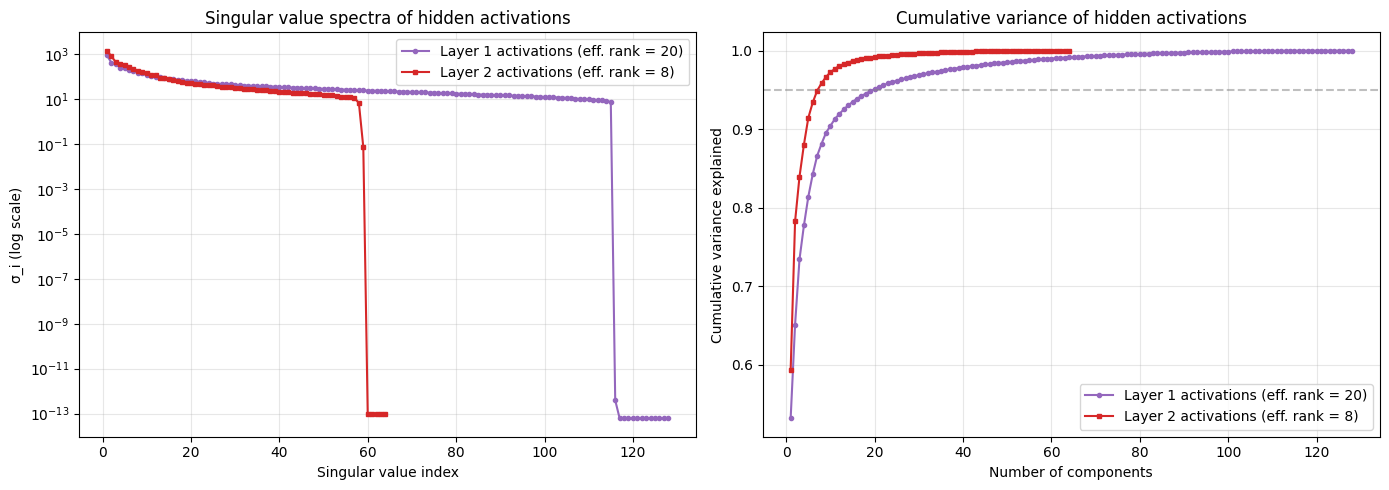

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.semilogy(range(1, len(svd_L1["S"])+1), svd_L1["S"], 'o-',
            label=f'Layer 1 activations (eff. rank = {svd_L1["eff_rank"]})',
            color='tab:purple', markersize=3)
ax.semilogy(range(1, len(svd_L2["S"])+1), svd_L2["S"], 's-',
            label=f'Layer 2 activations (eff. rank = {svd_L2["eff_rank"]})',
            color='tab:red', markersize=3)
ax.set_xlabel("Singular value index")
ax.set_ylabel("σ_i (log scale)")
ax.set_title("Singular value spectra of hidden activations")
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(range(1, len(svd_L1["var_explained"])+1),
        svd_L1["var_explained"], 'o-',
        label=f'Layer 1 activations (eff. rank = {svd_L1["eff_rank"]})',
        color='tab:purple', markersize=3)
ax.plot(range(1, len(svd_L2["var_explained"])+1),
        svd_L2["var_explained"], 's-',
        label=f'Layer 2 activations (eff. rank = {svd_L2["eff_rank"]})',
        color='tab:red', markersize=3)
ax.axhline(0.95, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel("Number of components")
ax.set_ylabel("Cumulative variance explained")
ax.set_title("Cumulative variance of hidden activations")
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Week 3 confirmed on Fashion-MNIST

Both layers have effective rank well below their nominal width. The
network solves a 10-class problem using a low-dimensional subspace of its
hidden representation — just as we saw on digits in Week 3.

**The question for this week**: what does this compression mean for the
network's sensitivity to input perturbations?

## Part 3 — Input Gradients

Implement the function to compute the gradient of the loss with respect to the input pixels.

In [2]:
def compute_input_gradient(model, x, y_true):
    '''Compute ∇_x L(x, y_true) for a single image. Returns (784,) tensor.'''
    # 1. Ensure the input image 'x' requires_grad
    # 2. Pass x through the model to get logits
    # 3. Compute CrossEntropy loss between logits and y_true
    # 4. Use loss.backward() to compute gradients
    # 5. Extract and return the gradient from x.grad
    pass

def show_image(ax, img_flat, title, cmap='gray', vmin=None, vmax=None):
    '''Helper function to display a flattened 784-dim vector as a 28x28 image.'''
    ax.imshow(img_flat.detach().reshape(28, 28).numpy(),
              cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=10)
    ax.axis('off')

## Part 4 — FGSM Attack

Implement the Fast Gradient Sign Method (FGSM) and a random perturbation baseline.

In [3]:
def fgsm_attack(model, x, y_true, epsilon):
    '''Single-step FGSM attack. Returns adversarial image clamped to [0,1].'''
    # 1. Get the gradient of the loss with respect to the input x
    # 2. Take the sign of the gradient
    # 3. Create the adversarial image: x_adv = x + epsilon * sign(grad)
    # 4. Clamp the result to [0, 1] to keep it a valid image
    pass

def random_attack(x, epsilon):
    '''Random uniform perturbation with same L_inf norm.'''
    # 1. Generate random noise in range [-epsilon, epsilon] with same shape as x
    # 2. Add noise to x and clamp to [0, 1]
    pass

In [ ]:
# --- Accuracy vs epsilon sweep: FGSM vs random ------------------------------
epsilons = np.arange(0, 0.35, 0.01)

n_eval = 2000
torch.manual_seed(0)
eval_idx = torch.randperm(len(Xte))[:n_eval]
X_eval = Xte[eval_idx]
y_eval = yte[eval_idx]

fgsm_accs = []
rand_accs = []

for eps in epsilons:
    if eps == 0:
        acc0 = accuracy(model, X_eval, y_eval)
        fgsm_accs.append(acc0)
        rand_accs.append(acc0)
        continue

    # FGSM
    x_adv_list = []
    for i in range(n_eval):
        x_adv_list.append(fgsm_attack(model, X_eval[i], y_eval[i], eps))
    X_adv = torch.stack(x_adv_list)
    fgsm_accs.append(accuracy(model, X_adv, y_eval))

    # Random
    noise = (2 * torch.rand_like(X_eval) - 1) * eps
    X_rand = (X_eval + noise).clamp(0, 1)
    rand_accs.append(accuracy(model, X_rand, y_eval))

    if eps in [0.05, 0.1, 0.15, 0.2, 0.3]:
        print(f"  ε = {eps:.2f}: FGSM acc = {fgsm_accs[-1]:.4f}, "
              f"Random acc = {rand_accs[-1]:.4f}")

  ε = 0.05: FGSM acc = 0.1405, Random acc = 0.8785
  ε = 0.10: FGSM acc = 0.0405, Random acc = 0.8615
  ε = 0.15: FGSM acc = 0.0205, Random acc = 0.8330
  ε = 0.20: FGSM acc = 0.0150, Random acc = 0.7975
  ε = 0.30: FGSM acc = 0.0080, Random acc = 0.6865


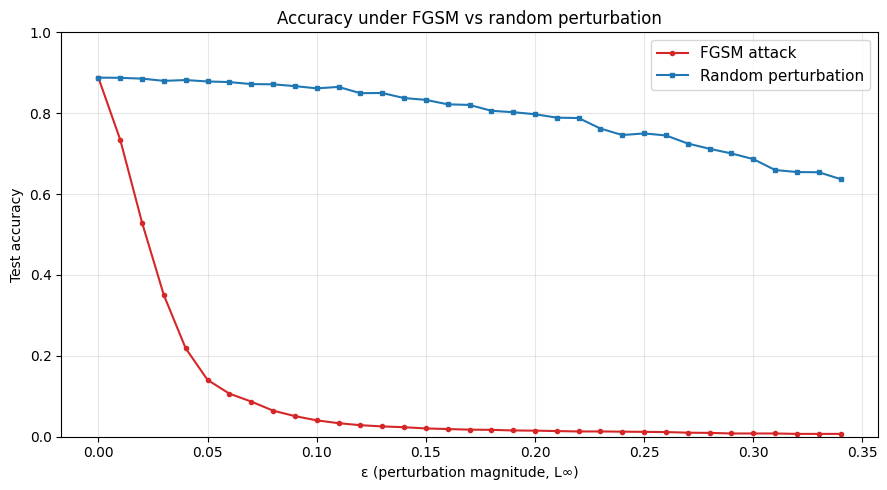

Recorded values:
  ε = 0.05: FGSM = 0.1405, Random = 0.8785
  ε = 0.1: FGSM = 0.0405, Random = 0.8615
  ε = 0.2: FGSM = 0.0150, Random = 0.7975


In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(epsilons, fgsm_accs, 'o-', label='FGSM attack', color='tab:red', markersize=3)
ax.plot(epsilons, rand_accs, 's-', label='Random perturbation', color='tab:blue', markersize=3)
ax.set_xlabel('ε (perturbation magnitude, L∞)')
ax.set_ylabel('Test accuracy')
ax.set_title('Accuracy under FGSM vs random perturbation')
ax.legend(fontsize=11); ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

print("Recorded values:")
for eps_target in [0.05, 0.1, 0.2]:
    idx_e = np.argmin(np.abs(epsilons - eps_target))
    print(f"  ε = {eps_target}: FGSM = {fgsm_accs[idx_e]:.4f}, "
          f"Random = {rand_accs[idx_e]:.4f}")

## Part 5 — The SVD of the Jacobian

Compute the Jacobian $J(x) = \partial f / \partial x$ and perform SVD to find the most sensitive directions.

In [4]:
def compute_jacobian(model, x):
    '''Compute J(x) = ∂f/∂x for a single input. Returns (10, 784) tensor.'''
    # Hint: Use torch.autograd.functional.jacobian.
    # You may need a wrapper function f(inp) that returns model(inp.unsqueeze(0)).squeeze(0)
    pass

# TODO: Select an image, compute its Jacobian J
# TODO: Perform SVD on J using torch.linalg.svd
# TODO: Calculate singular value statistics and effective rank

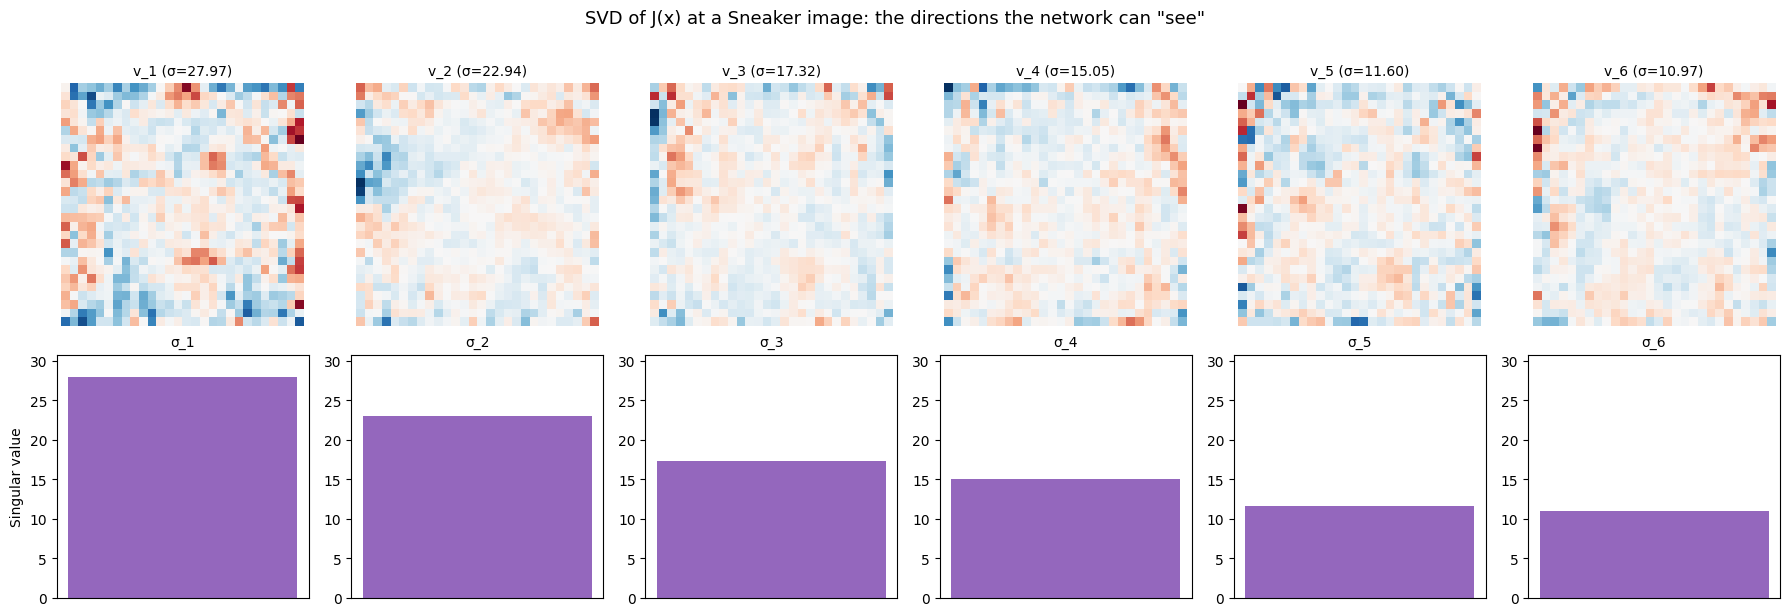

In [ ]:
# --- Visualize top right singular vectors of J as 28x28 images --------------
# v_i = i-th row of Vt = direction in input (pixel) space
n_show = min(6, len(S_J))
fig, axes = plt.subplots(2, n_show, figsize=(3*n_show, 6))

for i in range(n_show):
    v_i = Vt_J[i].numpy().reshape(28, 28)
    vmax = np.abs(v_i).max()

    ax = axes[0, i]
    ax.imshow(v_i, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    ax.set_title(f'v_{i+1} (σ={S_J[i]:.2f})', fontsize=10)
    ax.axis('off')

    axes[1, i].bar([0], [S_J[i].item()], color='tab:purple')
    axes[1, i].set_ylim(0, S_J[0].item() * 1.1)
    axes[1, i].set_title(f'σ_{i+1}', fontsize=10)
    axes[1, i].set_xticks([])

axes[0, 0].set_ylabel('Input direction\n(28×28)', fontsize=10)
axes[1, 0].set_ylabel('Singular value', fontsize=10)
plt.suptitle(f'SVD of J(x) at a {CLASS_NAMES[y_jac]} image: '
             f'the directions the network can "see"',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

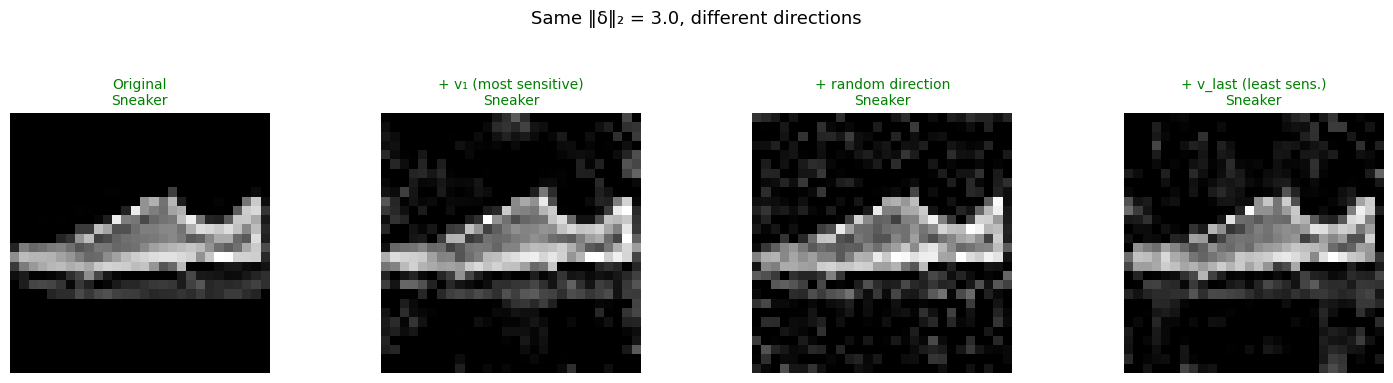

Output change (‖Δ logits‖₂):
  Along v₁ (most sensitive):   35.17
  Along random direction:      8.87
  Along v_last (least sens.):  6.98

Ratio v₁ / random: 4.0×
Ratio v₁ / v_last: 5.0×


In [ ]:
# --- Key experiment: same ‖δ‖₂, different directions -----------------------
pert_norm = 3.0

# Direction 1: top right singular vector (most sensitive)
v1 = Vt_J[0]
delta_v1 = pert_norm * v1 / v1.norm()

# Direction 2: random unit vector in 784-dim space
torch.manual_seed(42)
rand_dir = torch.randn(784)
delta_rand = pert_norm * rand_dir / rand_dir.norm()

# Direction 3: last right singular vector (least sensitive)
v_last = Vt_J[-1]
delta_vlast = pert_norm * v_last / v_last.norm()

x_v1    = (x_jac + delta_v1).clamp(0, 1)
x_rand  = (x_jac + delta_rand).clamp(0, 1)
x_vlast = (x_jac + delta_vlast).clamp(0, 1)

with torch.no_grad():
    logit_orig = model(x_jac.unsqueeze(0))
    pred_orig  = logit_orig.argmax(1).item()

    pred_v1    = model(x_v1.unsqueeze(0)).argmax(1).item()
    pred_rand  = model(x_rand.unsqueeze(0)).argmax(1).item()
    pred_vlast = model(x_vlast.unsqueeze(0)).argmax(1).item()

    change_v1    = (model(x_v1.unsqueeze(0)) - logit_orig).norm().item()
    change_rand  = (model(x_rand.unsqueeze(0)) - logit_orig).norm().item()
    change_vlast = (model(x_vlast.unsqueeze(0)) - logit_orig).norm().item()

fig, axes = plt.subplots(1, 4, figsize=(15, 3.5))

items = [
    (x_jac,   f'Original\n{CLASS_NAMES[pred_orig]}',          pred_orig, 0),
    (x_v1,    f'+ v₁ (most sensitive)\n{CLASS_NAMES[pred_v1]}', pred_v1,   change_v1),
    (x_rand,  f'+ random direction\n{CLASS_NAMES[pred_rand]}',  pred_rand, change_rand),
    (x_vlast, f'+ v_last (least sens.)\n{CLASS_NAMES[pred_vlast]}', pred_vlast, change_vlast),
]

for ax, (img, title, pred, change) in zip(axes, items):
    show_image(ax, img, '')
    color = 'red' if pred != pred_orig else 'green'
    ax.set_title(title, fontsize=10, color=color)
    if change > 0:
        ax.set_xlabel(f'Δ logits = {change:.2f}', fontsize=9)

plt.suptitle(f'Same ‖δ‖₂ = {pert_norm:.1f}, different directions', fontsize=13, y=1.08)
plt.tight_layout()
plt.show()

print(f"Output change (‖Δ logits‖₂):")
print(f"  Along v₁ (most sensitive):   {change_v1:.2f}")
print(f"  Along random direction:      {change_rand:.2f}")
print(f"  Along v_last (least sens.):  {change_vlast:.2f}")
print(f"\nRatio v₁ / random: {change_v1 / max(change_rand, 1e-8):.1f}×")
print(f"Ratio v₁ / v_last: {change_v1 / max(change_vlast, 1e-8):.1f}×")

## Part 6 — Weight Decay and Sensitivity

Compare a standard model with one trained using strong weight decay. Analyze how the spectral properties of the weights and the Jacobian norm change.

In [5]:
# 1. Initialize a new model (model_wd) with the same MLP architecture
# 2. Train model_wd using weight_decay=1e-2 in the train_mlp function
# 3. Compare the test accuracy of the standard model vs the weight_decay model
# 4. Analyze the weight norms using torch.linalg.norm(W, 2) for each layer

In [ ]:
# --- Compare weight matrix spectra and norms --------------------------------
def weight_analysis(model, label):
    '''Compute SVD stats and operator norms of weight matrices.'''
    W1 = model.fc1.weight.detach()   # (128, 784)
    W2 = model.fc2.weight.detach()   # (64, 128)
    W3 = model.fc3.weight.detach()   # (10, 64)

    results = {}
    for name, W in [('W1', W1), ('W2', W2), ('W3', W3)]:
        S = torch.linalg.svdvals(W)
        var = torch.cumsum(S**2, 0) / (S**2).sum()
        er = int(torch.searchsorted(var, 0.95).item()) + 1
        op_norm = S[0].item()    # ‖W‖₂ = σ_max
        results[name] = {'S': S.numpy(), 'eff_rank': er, 'op_norm': op_norm}
    return results

wa_no = weight_analysis(model, "No WD")
wa_wd = weight_analysis(model_wd, "WD=1e-2")

print(f"{'Layer':<6s}  {'eff_rank (no WD)':>18s}  {'eff_rank (WD)':>14s}  "
      f"{'‖W‖₂ (no WD)':>14s}  {'‖W‖₂ (WD)':>12s}")
print(f"{'─'*70}")
for name in ['W1', 'W2', 'W3']:
    print(f"{name:<6s}  {wa_no[name]['eff_rank']:>18d}  {wa_wd[name]['eff_rank']:>14d}  "
          f"{wa_no[name]['op_norm']:>14.4f}  {wa_wd[name]['op_norm']:>12.4f}")

# Product of operator norms: upper bound on ‖J‖
prod_no = wa_no['W1']['op_norm'] * wa_no['W2']['op_norm'] * wa_no['W3']['op_norm']
prod_wd = wa_wd['W1']['op_norm'] * wa_wd['W2']['op_norm'] * wa_wd['W3']['op_norm']
print(f"\n‖W1‖·‖W2‖·‖W3‖ (upper bound on ‖J‖):")
print(f"  No WD:    {prod_no:.2f}")
print(f"  WD=1e-2:  {prod_wd:.2f}")
print(f"  Ratio:    {prod_no / prod_wd:.1f}×")

Layer     eff_rank (no WD)   eff_rank (WD)    ‖W‖₂ (no WD)     ‖W‖₂ (WD)
──────────────────────────────────────────────────────────────────────
W1                      64              13         11.2325        1.7064
W2                      32               7          5.4329        2.1632
W3                       8               7          3.5678        2.0979

‖W1‖·‖W2‖·‖W3‖ (upper bound on ‖J‖):
  No WD:    217.73
  WD=1e-2:  7.74
  Ratio:    28.1×


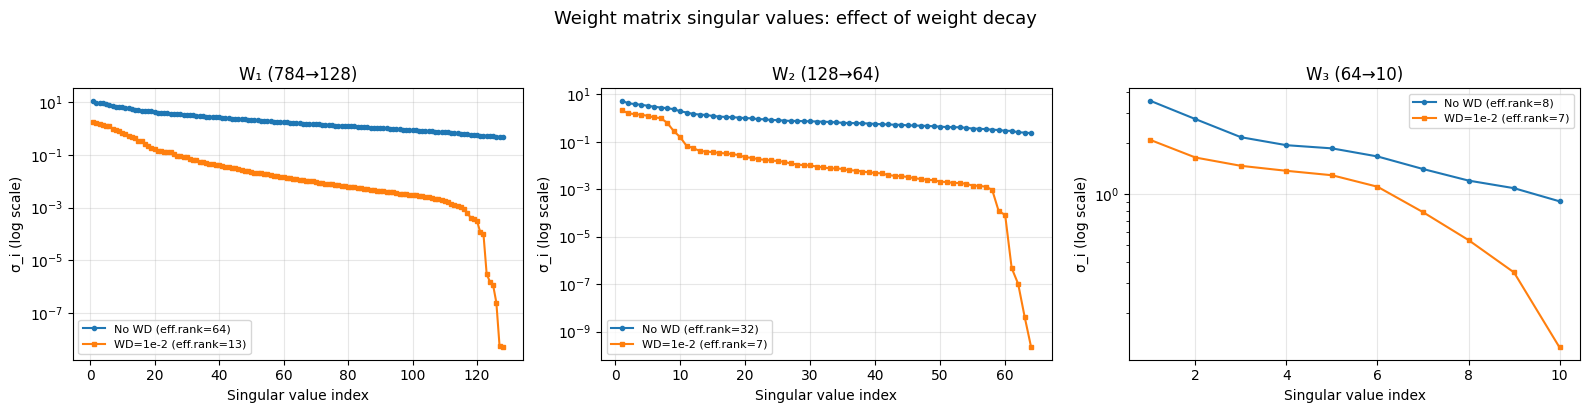

In [ ]:
# --- Weight matrix spectra side by side -------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, name, title in [(axes[0], 'W1', 'W₁ (784→128)'),
                          (axes[1], 'W2', 'W₂ (128→64)'),
                          (axes[2], 'W3', 'W₃ (64→10)')]:
    S_no = wa_no[name]['S']
    S_wd = wa_wd[name]['S']
    ax.semilogy(range(1, len(S_no)+1), S_no, 'o-',
                label=f'No WD (eff.rank={wa_no[name]["eff_rank"]})',
                color='tab:blue', markersize=3)
    ax.semilogy(range(1, len(S_wd)+1), S_wd, 's-',
                label=f'WD=1e-2 (eff.rank={wa_wd[name]["eff_rank"]})',
                color='tab:orange', markersize=3)
    ax.set_xlabel("Singular value index")
    ax.set_ylabel("σ_i (log scale)")
    ax.set_title(title)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle("Weight matrix singular values: effect of weight decay", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

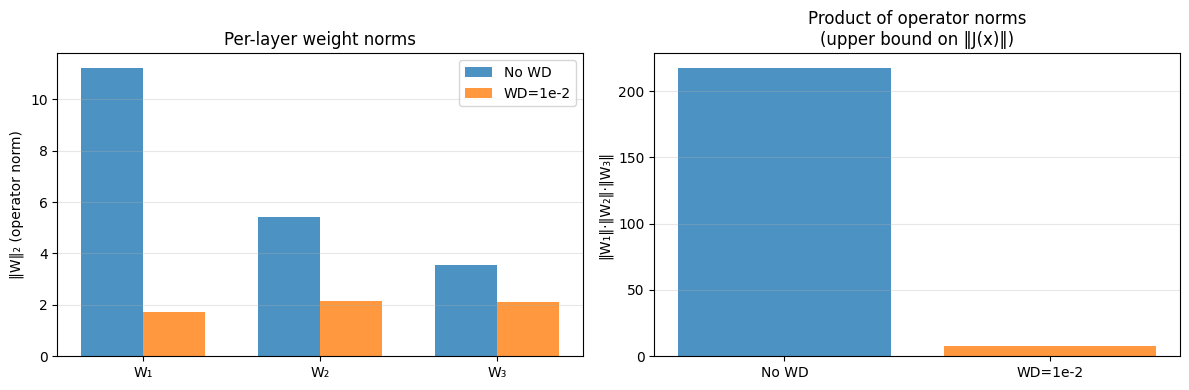

In [ ]:
# --- Operator norm bar chart ------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: per-layer operator norms
ax = axes[0]
layer_names = ['W₁', 'W₂', 'W₃']
x_pos = np.arange(3)
width = 0.35
bars_no = [wa_no[f'W{i+1}']['op_norm'] for i in range(3)]
bars_wd = [wa_wd[f'W{i+1}']['op_norm'] for i in range(3)]

ax.bar(x_pos - width/2, bars_no, width, label='No WD', color='tab:blue', alpha=0.8)
ax.bar(x_pos + width/2, bars_wd, width, label='WD=1e-2', color='tab:orange', alpha=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(layer_names)
ax.set_ylabel('‖W‖₂ (operator norm)')
ax.set_title('Per-layer weight norms')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')

# Right: product of norms (upper bound on ‖J‖)
ax = axes[1]
ax.bar(['No WD', 'WD=1e-2'], [prod_no, prod_wd],
       color=['tab:blue', 'tab:orange'], alpha=0.8)
ax.set_ylabel('‖W₁‖·‖W₂‖·‖W₃‖')
ax.set_title('Product of operator norms\n(upper bound on ‖J(x)‖)')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [ ]:
# --- Measure actual ‖J(x)‖ distribution for both models --------------------
def jacobian_norms(model, X, n_samples=300):
    '''Compute ‖J(x)‖₂ (= largest singular value) for n_samples inputs.'''
    norms = []
    indices = torch.randperm(len(X))[:n_samples]
    for i in indices:
        J = compute_jacobian(model, X[i])
        s1 = torch.linalg.svdvals(J)[0].item()
        norms.append(s1)
        if len(norms) % 100 == 0:
            print(f"  computed {len(norms)}/{n_samples} Jacobian norms...")
    return np.array(norms)

print("Computing ‖J(x)‖₂ for model without weight decay...")
jnorms_no = jacobian_norms(model, Xte, n_samples=300)
print("Computing ‖J(x)‖₂ for model with weight decay...")
jnorms_wd = jacobian_norms(model_wd, Xte, n_samples=300)

Computing ‖J(x)‖₂ for model without weight decay...
  computed 100/300 Jacobian norms...
  computed 200/300 Jacobian norms...
  computed 300/300 Jacobian norms...
Computing ‖J(x)‖₂ for model with weight decay...
  computed 100/300 Jacobian norms...
  computed 200/300 Jacobian norms...
  computed 300/300 Jacobian norms...


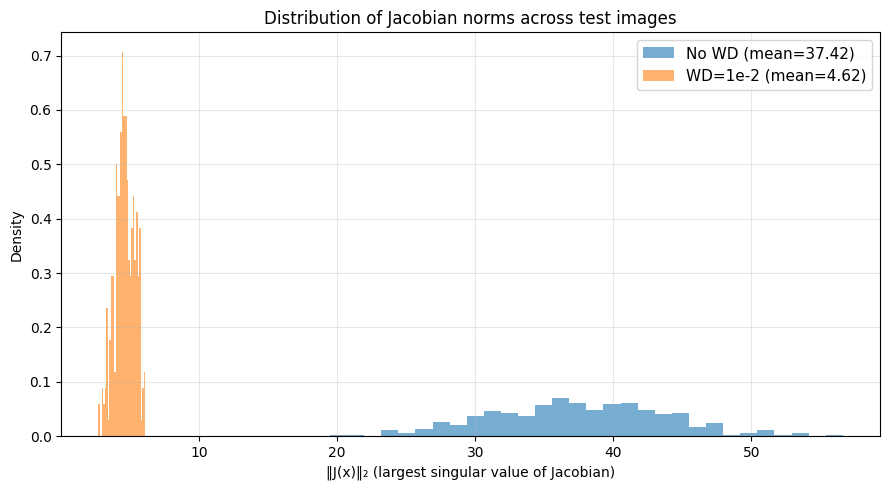

‖J(x)‖₂ statistics:
  No WD:    mean = 37.42, median = 37.38
  WD=1e-2:  mean = 4.62, median = 4.61
  Ratio of means: 8.1×


In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(jnorms_no, bins=30, alpha=0.6, label=f'No WD (mean={jnorms_no.mean():.2f})',
        color='tab:blue', density=True)
ax.hist(jnorms_wd, bins=30, alpha=0.6, label=f'WD=1e-2 (mean={jnorms_wd.mean():.2f})',
        color='tab:orange', density=True)
ax.set_xlabel('‖J(x)‖₂ (largest singular value of Jacobian)')
ax.set_ylabel('Density')
ax.set_title('Distribution of Jacobian norms across test images')
ax.legend(fontsize=11); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"‖J(x)‖₂ statistics:")
print(f"  No WD:    mean = {jnorms_no.mean():.2f}, median = {np.median(jnorms_no):.2f}")
print(f"  WD=1e-2:  mean = {jnorms_wd.mean():.2f}, median = {np.median(jnorms_wd):.2f}")
print(f"  Ratio of means: {jnorms_no.mean() / jnorms_wd.mean():.1f}×")

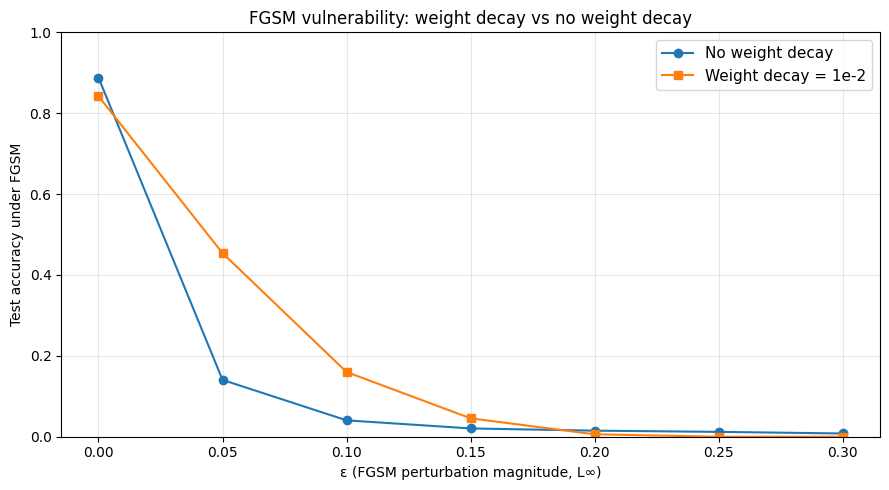

FGSM accuracy comparison:
  ε = 0.00: No WD = 0.8880, WD = 0.8420
  ε = 0.05: No WD = 0.1405, WD = 0.4540
  ε = 0.10: No WD = 0.0405, WD = 0.1600
  ε = 0.15: No WD = 0.0205, WD = 0.0455
  ε = 0.20: No WD = 0.0150, WD = 0.0060
  ε = 0.25: No WD = 0.0120, WD = 0.0000
  ε = 0.30: No WD = 0.0080, WD = 0.0000


In [ ]:
# --- FGSM comparison: no WD vs WD -------------------------------------------
eps_compare = [0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3]

fgsm_accs_wd = []
for eps in eps_compare:
    if eps == 0:
        fgsm_accs_wd.append(accuracy(model_wd, X_eval, y_eval))
        continue
    x_adv_list = []
    for i in range(n_eval):
        x_adv_list.append(fgsm_attack(model_wd, X_eval[i], y_eval[i], eps))
    X_adv = torch.stack(x_adv_list)
    fgsm_accs_wd.append(accuracy(model_wd, X_adv, y_eval))

fgsm_accs_orig = []
for eps in eps_compare:
    idx_e = np.argmin(np.abs(epsilons - eps))
    fgsm_accs_orig.append(fgsm_accs[idx_e])

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(eps_compare, fgsm_accs_orig, 'o-', label='No weight decay', color='tab:blue')
ax.plot(eps_compare, fgsm_accs_wd, 's-', label='Weight decay = 1e-2', color='tab:orange')
ax.set_xlabel('ε (FGSM perturbation magnitude, L∞)')
ax.set_ylabel('Test accuracy under FGSM')
ax.set_title('FGSM vulnerability: weight decay vs no weight decay')
ax.legend(fontsize=11); ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

print("FGSM accuracy comparison:")
for i, eps in enumerate(eps_compare):
    print(f"  ε = {eps:.2f}: No WD = {fgsm_accs_orig[i]:.4f}, "
          f"WD = {fgsm_accs_wd[i]:.4f}")